In [30]:
# ============================================================
# Yelp Reviews EDA Example for CS3
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from google.colab import files
df = pd.read_csv("Yelp Restaurant Reviews.csv")

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df = df.rename(columns={
    "yelp_url": "url",
    "review_text": "text"
})

print("Dataset shape:", df.shape)
print(df.head())
print(df.isna().sum())

Dataset shape: (19896, 4)
                                                 url  rating       date  \
0  https://www.yelp.com/biz/sidney-dairy-barn-sidney       5  1/22/2022   
1  https://www.yelp.com/biz/sidney-dairy-barn-sidney       4  6/26/2022   
2  https://www.yelp.com/biz/sidney-dairy-barn-sidney       5   8/7/2021   
3  https://www.yelp.com/biz/sidney-dairy-barn-sidney       4  7/28/2016   
4  https://www.yelp.com/biz/sidney-dairy-barn-sidney       5  6/23/2015   

                                                text  
0  All I can say is they have very good ice cream...  
1  Nice little local place for ice cream.My favor...  
2  A delicious treat on a hot day! Staff was very...  
3  This was great service and a fun crew! I got t...  
4  This is one of my favorite places to get ice c...  
url       0
rating    0
date      0
text      0
dtype: int64


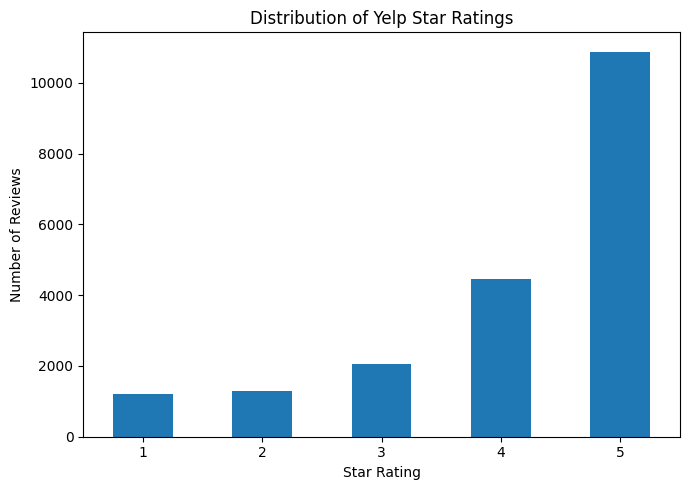

In [31]:
# ============================================================
# 1. Rating Distribution
# ============================================================

plt.figure(figsize=(7, 5))
df["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Yelp Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("01_rating_distribution.png", dpi=300)
plt.show()

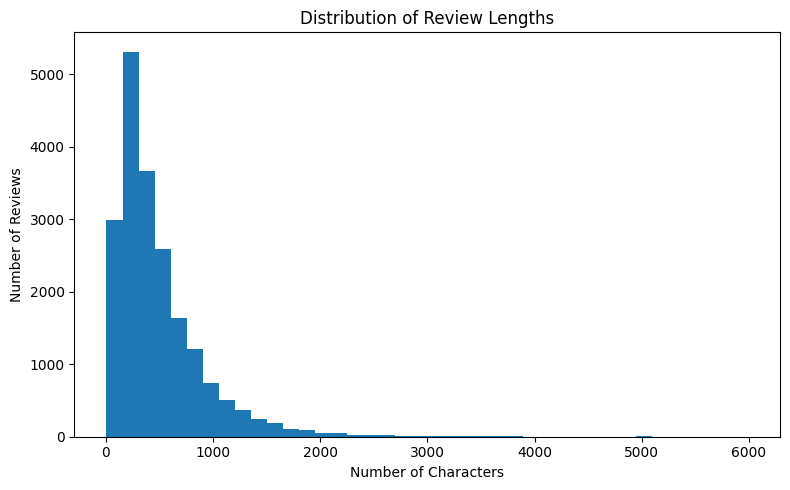

In [32]:
# ============================================================
# 2. Review Length Distribution
# ============================================================

df["review_length"] = df["text"].astype(str).apply(len)

plt.figure(figsize=(8, 5))
plt.hist(df["review_length"], bins=40)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")
plt.tight_layout()

plt.savefig("02_review_length_distribution.png", dpi=300)
plt.show()

In [33]:
# ============================================================
# 3. Clean and Tokenize Review Text
# ============================================================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    stopwords = set(ENGLISH_STOP_WORDS)
    words = text.split()
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return words

df["text_clean"] = df["text"].apply(clean_text)
df["tokens"] = df["text_clean"].apply(tokenize)

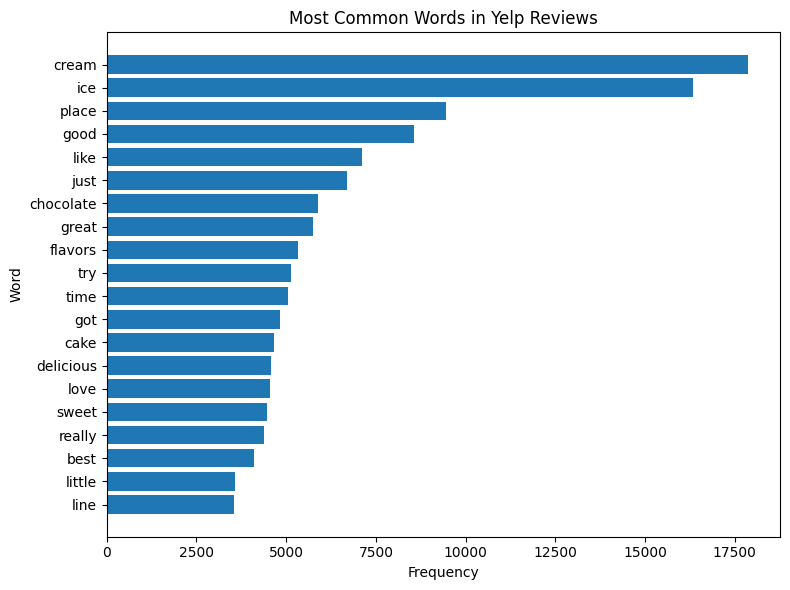

,word,count
0,cream,17868
1,ice,16338
2,place,9449
3,good,8559
4,like,7108
5,just,6690
6,chocolate,5881
7,great,5737
8,flavors,5324
9,try,5123


In [34]:
# ============================================================
# 4. Most Common Words
# ============================================================

all_words = [word for tokens in df["tokens"] for word in tokens]
word_counts = Counter(all_words)

common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

plt.figure(figsize=(8, 6))
plt.barh(common_words["word"][::-1], common_words["count"][::-1])

plt.title("Most Common Words in Yelp Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()

plt.savefig("03_most_common_words.png", dpi=300)
plt.show()

common_words

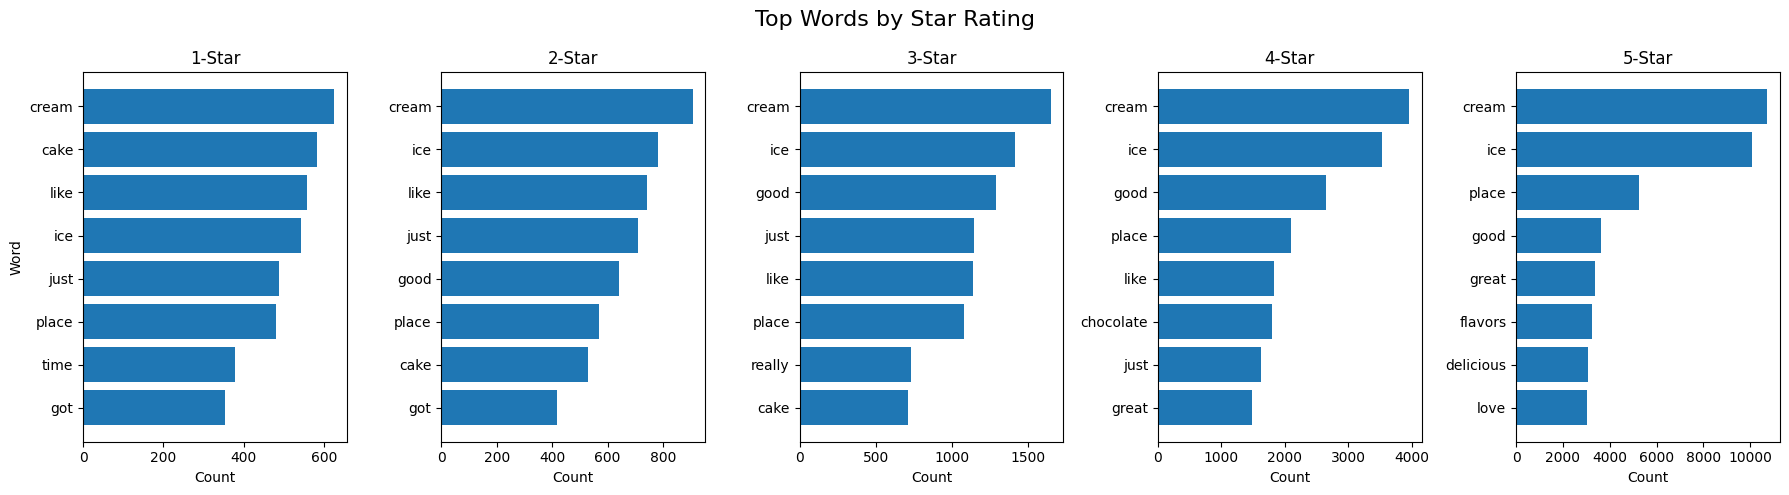

In [35]:
# ============================================================
# 5. Top Words by Star Rating
# ============================================================

top_words_by_rating = []

for rating in sorted(df["rating"].unique()):
    rating_words = [
        word
        for tokens in df.loc[df["rating"] == rating, "tokens"]
        for word in tokens
    ]

    top_words = Counter(rating_words).most_common(8)

    for word, count in top_words:
        top_words_by_rating.append({
            "rating": rating,
            "word": word,
            "count": count
        })

top_words_by_rating = pd.DataFrame(top_words_by_rating)

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=False)

for ax, rating in zip(axes, sorted(df["rating"].unique())):
    data = top_words_by_rating[top_words_by_rating["rating"] == rating]
    ax.barh(data["word"][::-1], data["count"][::-1])
    ax.set_title(f"{rating}-Star")
    ax.set_xlabel("Count")

axes[0].set_ylabel("Word")
fig.suptitle("Top Words by Star Rating", fontsize=16)
plt.tight_layout()

plt.savefig("04_top_words_by_rating.png", dpi=300)
plt.show()

In [36]:
# ============================================================
# 6. Remove Dessert / Topic-Specific Words
# ============================================================
# These words appeared often, but mostly describe the type of food rather than customer sentiment.

food_stopwords = {
    "ice", "cream", "chocolate", "vanilla", "cookie", "cookies",
    "cake", "cakes", "flavor", "flavors", "bakery", "donut", "donuts",
    "milk", "frosting", "icing", "dessert", "desserts", "sweet", "sweets"
}

def remove_food_words(tokens):
    return [word for word in tokens if word not in food_stopwords]

df["tokens_no_food"] = df["tokens"].apply(remove_food_words)

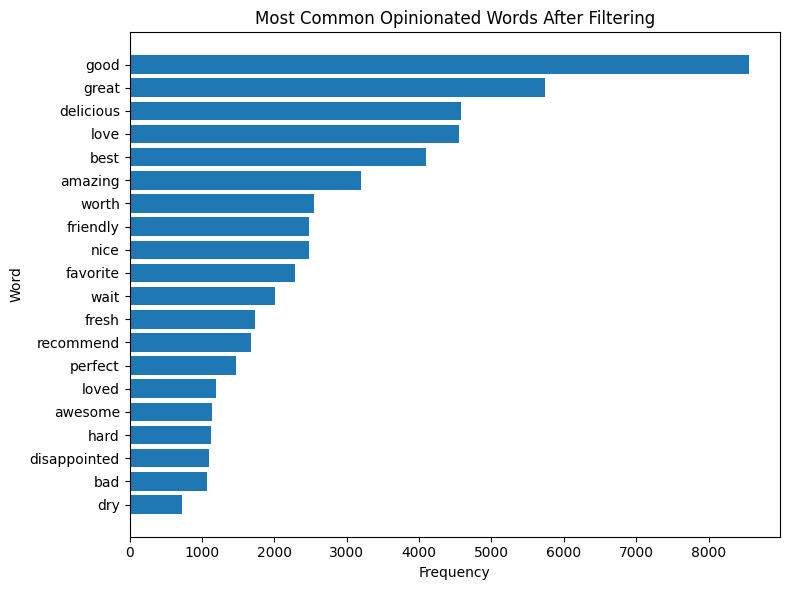

,word,count
0,good,8559
1,great,5737
2,delicious,4582
3,love,4558
4,best,4091
5,amazing,3194
6,worth,2553
7,friendly,2482
8,nice,2474
9,favorite,2280


In [37]:
# ============================================================
# 7. Opinionated Words After Filtering
# ============================================================

opinion_words = {
    "amazing", "delicious", "love", "loved", "favorite", "friendly",
    "perfect", "nice", "fresh", "recommend", "worth", "great",
    "excellent", "best", "awesome", "good", "bad", "rude",
    "disappointed", "hard", "wait", "slow", "terrible", "poor",
    "dry", "worst", "awful", "overpriced"
}

def keep_opinion_words(tokens):
    return [word for word in tokens if word in opinion_words]

df["opinion_tokens"] = df["tokens_no_food"].apply(keep_opinion_words)

all_opinion_words = [
    word for tokens in df["opinion_tokens"] for word in tokens
]

opinion_word_counts = Counter(all_opinion_words)

opinion_words_df = pd.DataFrame(
    opinion_word_counts.most_common(20),
    columns=["word", "count"]
)

plt.figure(figsize=(8, 6))
plt.barh(opinion_words_df["word"][::-1], opinion_words_df["count"][::-1])

plt.title("Most Common Opinionated Words After Filtering")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()

plt.savefig("05_opinionated_words_after_filtering.png", dpi=300)
plt.show()

opinion_words_df